In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel('std_data.xlsx', header=1)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()

,Student_ID,Student_Name,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Assignments_Submitted,Sleep_Hours,Final_Marks
0,STU001,Fatima Noor,4.4,90.4,3.85,1.0,6.1,100.0
1,STU002,Ali Hassan,9.6,94.8,3.88,2.0,8.5,100.0
2,STU003,Hamza Sheikh,NaN,65.9,NaN,0.0,4.6,96.5
3,STU004,Zainab Hussain,6.4,55.5,2.43,0.0,NaN,83.8
4,STU005,Zainab Hussain,99.0,NaN,1.54,2.0,NaN,60.7


In [3]:
df.describe()

,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Final_Marks
count,114.000000,114.000000,115.000000,125.000000
mean,6.160526,75.514912,2.848870,99.379200
std,9.401399,21.434045,1.069368,82.321862
min,-3.000000,-10.000000,-1.000000,-5.000000
25%,2.800000,62.025000,2.235000,86.800000
50%,5.300000,75.300000,2.870000,97.200000
75%,7.900000,86.375000,3.370000,100.000000
max,99.000000,200.000000,9.900000,999.000000


# Data me mising value aur nun value fill karne ke leye

In [4]:
df['Study_Hours_Per_Day'] = df['Study_Hours_Per_Day'].fillna(df['Study_Hours_Per_Day'].mean())

In [5]:
df = df[df['Study_Hours_Per_Day'] < 24] 

In [6]:
df['Attendance_%'] = df['Attendance_%'].fillna(df['Attendance_%'].mean())

In [7]:
df['Previous_GPA'] = df['Previous_GPA'].fillna(df['Previous_GPA'].median())

In [8]:
df = df.drop_duplicates(subset=['Student_ID'], keep='first') 

In [9]:
df = df.drop_duplicates()

In [10]:
df.head()

,Student_ID,Student_Name,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Assignments_Submitted,Sleep_Hours,Final_Marks
0,STU001,Fatima Noor,4.400000,90.4,3.85,1.0,6.1,100.0
1,STU002,Ali Hassan,9.600000,94.8,3.88,2.0,8.5,100.0
2,STU003,Hamza Sheikh,6.160526,65.9,2.87,0.0,4.6,96.5
3,STU004,Zainab Hussain,6.400000,55.5,2.43,0.0,NaN,83.8
5,STU006,Bilal Ahmed,2.400000,71.4,3.82,4.0,6.3,93.7


In [11]:
df = df.drop(['Student_ID', 'Student_Name'], axis=1)
df = df.fillna(df.median(numeric_only=True))
df.isnull().sum().sum()

np.int64(8)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 0 to 119
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours_Per_Day    118 non-null    float64
 1   Attendance_%           118 non-null    float64
 2   Previous_GPA           118 non-null    float64
 3   Assignments_Submitted  118 non-null    object 
 4   Sleep_Hours            110 non-null    object 
 5   Final_Marks            118 non-null    float64
dtypes: float64(4), object(2)
memory usage: 6.5+ KB


In [13]:
# ye code Sleep_Hours me object ko num me canvart ke liye
df['Sleep_Hours'] = pd.to_numeric(df['Sleep_Hours'], errors='coerce')

In [14]:
#  Fainal data cleening
df['Assignments_Submitted'] = pd.to_numeric(df['Assignments_Submitted'], errors='coerce')
df['Sleep_Hours'] = df['Sleep_Hours'].fillna(df['Sleep_Hours'].median())
df['Assignments_Submitted'] = df['Assignments_Submitted'].fillna(df['Assignments_Submitted'].mean())
df.isnull().sum()

Study_Hours_Per_Day      0
Attendance_%             0
Previous_GPA             0
Assignments_Submitted    0
Sleep_Hours              0
Final_Marks              0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 0 to 119
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours_Per_Day    118 non-null    float64
 1   Attendance_%           118 non-null    float64
 2   Previous_GPA           118 non-null    float64
 3   Assignments_Submitted  118 non-null    float64
 4   Sleep_Hours            118 non-null    float64
 5   Final_Marks            118 non-null    float64
dtypes: float64(6)
memory usage: 6.5 KB


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_selector, ColumnTransformer

In [17]:
X = df.drop("Final_Marks", axis=1)
y = df["Final_Marks"]

In [18]:
X.columns

Index(['Study_Hours_Per_Day', 'Attendance_%', 'Previous_GPA',
       'Assignments_Submitted', 'Sleep_Hours'],
      dtype='object')

In [19]:
y.name

'Final_Marks'

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [21]:
cat_cols = X_train.select_dtypes('object').columns
num_cols = X_train.select_dtypes('number').columns


# Preprocessing Pipelines

In [22]:
num_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="median")), 
    ("scaling", StandardScaler())]
)


In [23]:
cat_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy="most_frequent")), 
    ("encoder", OneHotEncoder())]
)

# Column Transformer (AUTO)

In [24]:
preprocessor = ColumnTransformer([
                            ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
                            ("cat", cat_pipeline, make_column_selector(dtype_include=object))
])

In [25]:
num_imputer = SimpleImputer(strategy="median")

In [26]:
cat_imputer = SimpleImputer(strategy="most_frequent")

In [27]:
# Pipeline

num_pipeline = Pipeline([
    ("imputer", num_imputer),
    ("scaler", StandardScaler())
])

In [28]:
cat_pipeline = Pipeline([
    ("imputer", cat_imputer),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [29]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [30]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42
)

In [32]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  Index(['Study_Hours_Per_Day', 'Attendance_%', 'Previous_GPA',
       'Assignments_Submitted', 'Sleep_Hours'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('model', LinearRegression())])

In [33]:
y_pred = pipeline.predict(X_test)

# R2 Score

In [34]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -1.2812263808226807


In [35]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 22.207333043972703


In [36]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 976.3139571013168


# Plt Scatter

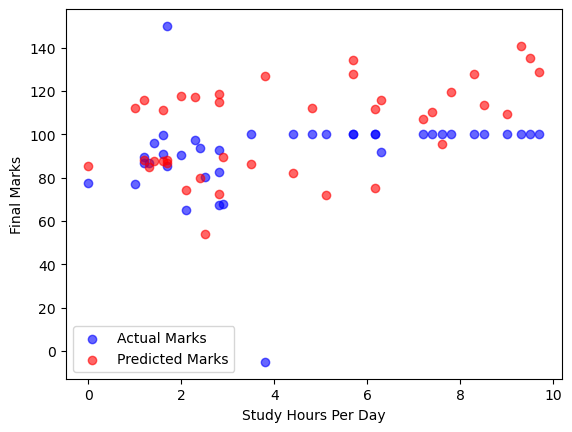

In [37]:

plt.scatter(x=X_test['Study_Hours_Per_Day'], y=y_test, 
            color='blue', alpha=0.6, label='Actual Marks')

plt.scatter(x=X_test['Study_Hours_Per_Day'], y=y_pred, 
            color='red', alpha=0.6, label='Predicted Marks')

plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Marks')
plt.legend()
plt.show()

In [38]:
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

In [39]:
X = X.fillna(X.median())

In [40]:
print(X.dtypes)

Study_Hours_Per_Day      float64
Attendance_%             float64
Previous_GPA             float64
Assignments_Submitted    float64
Sleep_Hours              float64
dtype: object


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), X.columns.tolist())
    ])

In [43]:
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours_Per_Day',
                                                   'Attendance_%',
                                                   'Previous_GPA',
                                                   'Assignments_Submitted',
                                                   'Sleep_Hours'])])),
                ('model', LinearRegression())])

In [46]:
y_pred = linear_pipeline.predict(X_test)

In [47]:
from sklearn.metrics import r2_score, mean_absolute_error
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: -3.0908469142133237
MAE: 15.994028131230912


In [48]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
linear_pipeline.fit(X_train, y_train)
y_pred = linear_pipeline.predict(X_test)

In [49]:
from sklearn.metrics import r2_score, mean_absolute_error
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: -1.1951024207633378
MAE: 22.33304187791342


In [50]:
print(X.columns.tolist())

['Study_Hours_Per_Day', 'Attendance_%', 'Previous_GPA', 'Assignments_Submitted', 'Sleep_Hours']


In [51]:
import numpy as np
y_baseline = np.full_like(y_test, y_train.mean())
print("Baseline MAE:", mean_absolute_error(y_test, y_baseline))

Baseline MAE: 15.171205962059613


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 0 to 119
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours_Per_Day    118 non-null    float64
 1   Attendance_%           118 non-null    float64
 2   Previous_GPA           118 non-null    float64
 3   Assignments_Submitted  118 non-null    float64
 4   Sleep_Hours            118 non-null    float64
 5   Final_Marks            118 non-null    float64
dtypes: float64(6)
memory usage: 6.5 KB


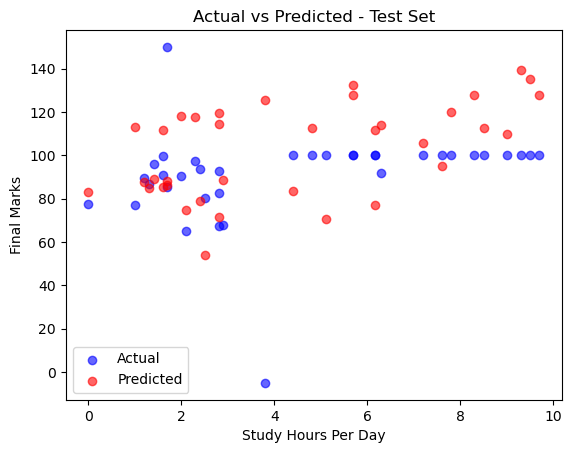

In [53]:
import matplotlib.pyplot as plt

plt.scatter(X_test['Study_Hours_Per_Day'], y_test, 
            color='blue', alpha=0.6, label='Actual')

plt.scatter(X_test['Study_Hours_Per_Day'], y_pred, 
            color='red', alpha=0.6, label='Predicted')

plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Marks')
plt.title('Actual vs Predicted - Test Set')
plt.legend()
plt.show()

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: -1.1951024207633378
MAE: 22.33304187791342
